In [184]:
from multiprocessing import Pool,Process,Manager,cpu_count
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
import pickle
from PIL import Image,ImageFilter
import warnings
import scipy.optimize as opt
import scipy as sp
import cmath
import time 
import math

%matplotlib inline
warnings.filterwarnings('ignore')

font = {'family' : 'Ubuntu',
        'weight' : 'normal',
        'size'   : 30}

matplotlib.rc('font', **font)


In [185]:
def ListofFiles(path):
    filelist=[]
    for root, dirs, files in os.walk(path):
        for file in files:
             filelist.append(os.path.join(root,file))
    return filelist

def getImageValues(Files,EventLimit=1):
    if(type(Files) is list):
        values={}
        count=0
        for file in Files:
            img1=Image.open(file)
            imgArray=np.array(img1)
            values[count]=imgArray
            count+=1
            if(EventLimit==count):
                break
        print(f" {count} frames in dictinary ")
    else:
        img1=Image.open(Files)
        values=np.array(img1)
    return values

def PickleITDump(data,fileName):
    with open(fileName,'wb') as f:
        pickle.dump(data,f)
        
def PickleITRead(fileName):
    with open(fileName,'rb') as f:
        data=pickle.load(f)
    return data

def AvergImage(Images,rangex,Single=True,start=0):
    img=np.zeros(Images[0].shape)
    if (rangex>len(Images.keys())):
        rangex=len(Images.keys())
    # Average only one set
    if(Single):
        for i in range(start,rangex+start):
            img+=Images[i]
        img=img/rangex
        return img
    else: # Average Multiple Sets of Images
        cnt=0
        fImages=[]
        while(cnt<=len(Images.keys())-1):
            img+=Images[cnt]
            if (cnt%(rangex)==0 and cnt>0):
                fImages.append(img/rangex)
                img=np.zeros(Images[0].shape)
            cnt=cnt+1
        return fImages
    

    
### Handling S1s 
def GetMask(Field,imgs,isPlot=True):
    PixelShape=(512,512)
    OffsetY=+42 #-25
    OffsetX=-25 #+20
    Test_=AvergImage(imgs,len(imgs),Single=True,start=0)
    
    AdjustedOffset_14cm=(215+OffsetX-25,270+OffsetY)
    AdjustedOffset_9cm=(309+OffsetX+20,306+OffsetY+20)
    AdjustedOffset_4cm=(261+OffsetX,180+OffsetY)
    AdjustedRadius=[35,35,35]

    Needle14cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[0],AdjustedOffset_14cm)

    Needle9cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[1],AdjustedOffset_9cm)

    Needle4cmMaskInitial=MaskCreate(PixelShape,AdjustedRadius[2],AdjustedOffset_4cm)

    EsitmatedCenter4cm=WeightedAverage(Test_,Needle14cmMaskInitial,AdjustedRadius[0])
    EsitmatedCenter9cm=WeightedAverage(Test_,Needle9cmMaskInitial,AdjustedRadius[1])
    EsitmatedCenter14cm=WeightedAverage(Test_,Needle4cmMaskInitial,AdjustedRadius[2])

    Needle14cmMask_=MaskCreate(PixelShape,AdjustedRadius[0],(EsitmatedCenter4cm[0][0],EsitmatedCenter4cm[0][1]))

    Needle9cmMask_=MaskCreate(PixelShape,AdjustedRadius[1],(EsitmatedCenter9cm[0][0],EsitmatedCenter9cm[0][1]))

    Needle4cmMask_=MaskCreate(PixelShape,AdjustedRadius[2],(EsitmatedCenter14cm[0][0],EsitmatedCenter14cm[0][1]))
    RectangleMask_=MaskCreate(PixelShape,(50,50),(100,420),sp="Rectangle")

    if(isPlot):
        fig,(ax1,ax2)=plt.subplots(1,2)
        fig.set_figwidth(15)
        fig.set_figheight(15)
        ax1.imshow((Test_*RectangleMask_[0])+(Test_*Needle4cmMask_[0])+(Test_*Needle9cmMask_[0])+(Test_*Needle14cmMask_[0]),origin="lower")
        ax2.imshow(Test_,origin="lower")
    
    return Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,RectangleMask_,Test_


def getLightyields(Path,fields,isplot=False,Avg=0):
    All={}
    for field in fields:
        FullPath=Path+field
        Imgs=getImageValues(ListofFiles(FullPath),600)
        if(len(Imgs)==0):
            print("Skipping since there are no frames ..")
            continue
        else:
            print(f"Analyzing {field}")
        Needle4cmMask_,Needle9cmMask_,Needle14cmMask_,Noise_,AvgImg=GetMask(field,Imgs,isplot)    
        Results={"4cm":np.array([]),"9cm":np.array([]),"14cm":np.array([]),"4cm_mean":np.array([]),"9cm_mean":np.array([]),"14cm_mean":np.array([]),"WholeImage":np.array([])}
        if(Avg!=0):
            Imgs_=AvergImage(Imgs,Avg,Single=False,start=0,isDic=True)
        else:
            Imgs_=Imgs
        for i in Imgs_:
            MeanNoise=np.mean(Imgs_[i][Noise_[0]])
            #print(MeanNoise)
            Imgs_[i]=abs(Imgs_[i]-MeanNoise)
            if(np.sum(Imgs_[i][Needle4cmMask_[0]])<0 or np.sum(Imgs_[i][Needle9cmMask_[0]])<0 or np.sum(Imgs_[i][Needle14cmMask_[0]])<0):
                continue
            Results["4cm"]=np.append(Results["4cm"],np.sum(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm"]=np.append(Results["9cm"],np.sum(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm"]=np.append(Results["14cm"],np.sum(Imgs_[i][Needle14cmMask_[0]]))
            Results["4cm_mean"]=np.append(Results["4cm_mean"],np.mean(Imgs_[i][Needle4cmMask_[0]]))
            Results["9cm_mean"]=np.append(Results["9cm_mean"],np.mean(Imgs_[i][Needle9cmMask_[0]]))
            Results["14cm_mean"]=np.append(Results["14cm_mean"],np.mean(Imgs_[i][Needle14cmMask_[0]]))
            Results["WholeImage"]=np.append(Results["WholeImage"],np.sum(Imgs_[i]))

        colors=["red","green","blue"]
        FitResult=FitAndPlot(Results,colors,field,isplot=isplot)
        All[field]=FitResult,Results,AvgImg
    return All    

In [186]:
#NewImageIntensifier=AvergImage(NewIIImages,rangex=1000,Single=True)

In [187]:
#OlderImageIntensifier=AvergImage(Images,rangex=1000,Single=True)
OlderImageIntensifier=PickleITRead("OlderII.p")
NewImageIntensifier=PickleITRead("NewII.p")

In [188]:
len(NewImageIntensifier)

512

In [189]:
OlderCut=OlderImageIntensifier/np.mean(OlderImageIntensifier)
NewerCut=NewImageIntensifier/np.mean(NewImageIntensifier)

print(f" Old II Min is {np.mean(OlderCut)} and Max {np.max(OlderCut)}")
print(f" New II Min is {np.mean(NewerCut)} and Max {np.max(NewerCut)}")

 Old II Min is 1.0000000000000002 and Max 1.1354365477674915
 New II Min is 1.0 and Max 3.3175767023081577


In [190]:
np.mean(NewerCut)

1.0

 Old II Min is 1.0000000000000002 and Max 1.1354365477674915
 New II Min is 1.0 and Max 3.3175767023081577


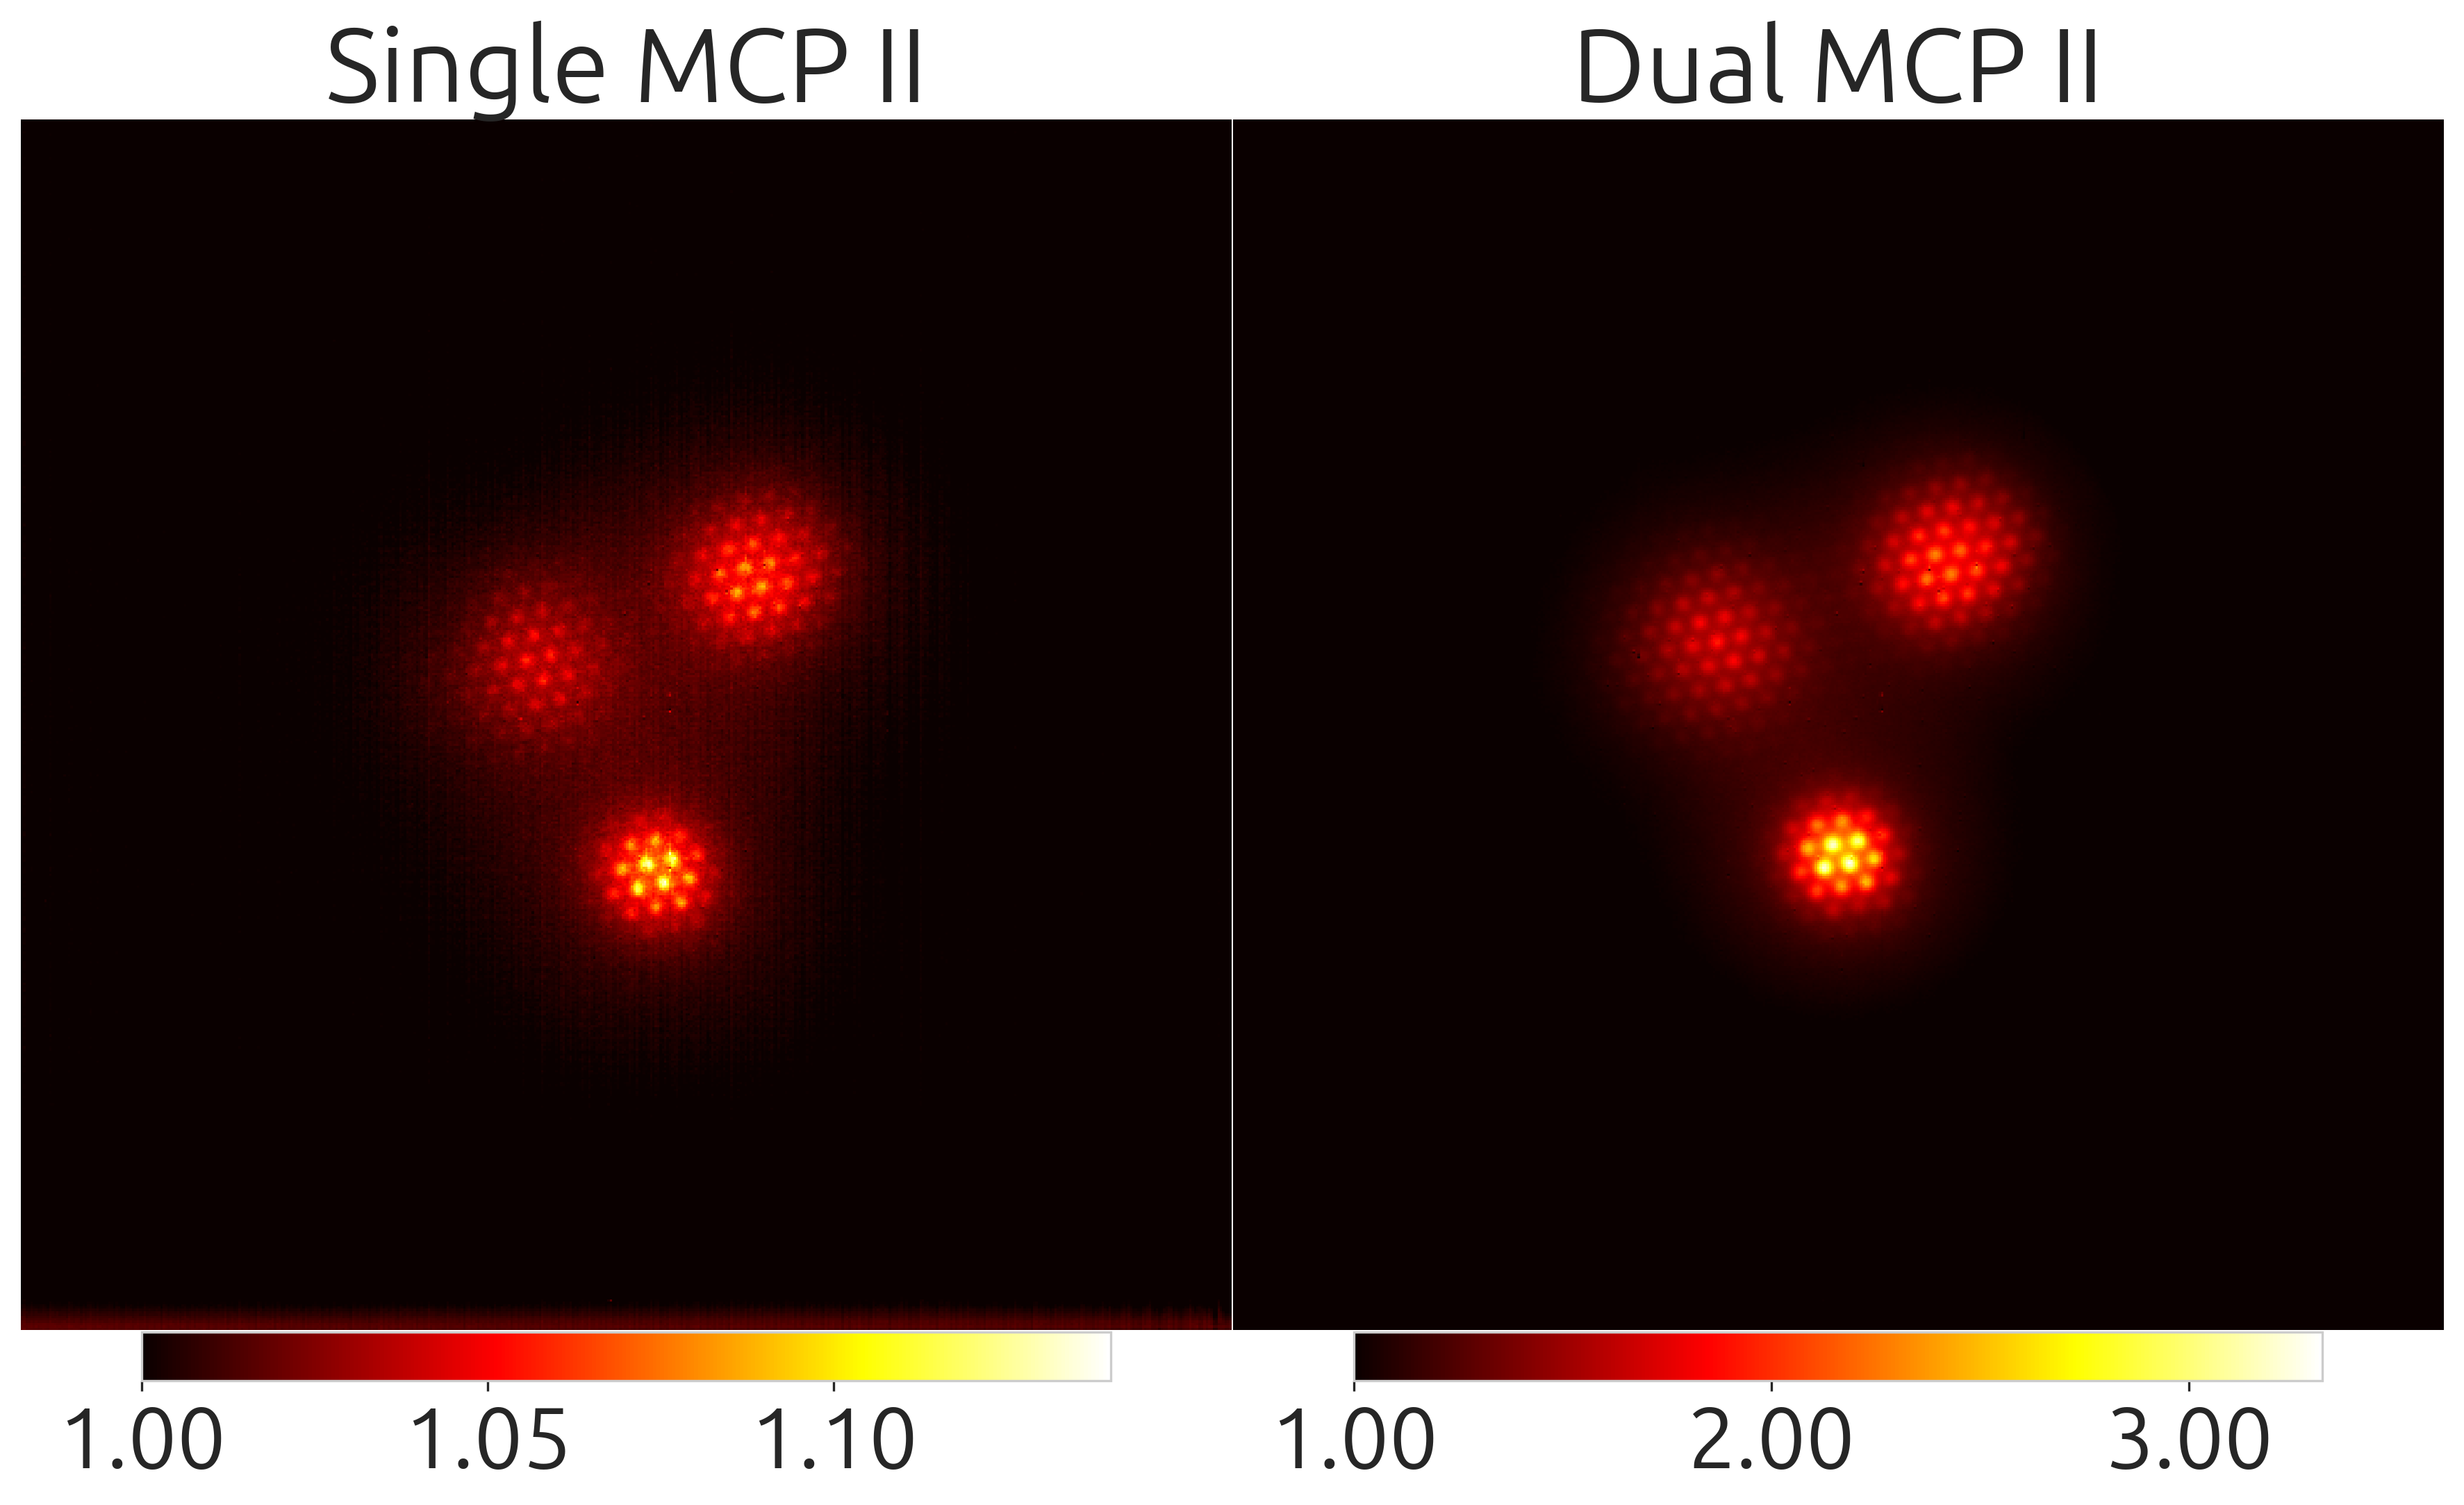

In [191]:
import matplotlib as mpl
import matplotlib.colors as mc
from mpl_toolkits.axes_grid1 import make_axes_locatable
#OlderCut=OlderImageIntensifier-np.mean(OlderImageIntensifier)
#NewerCut=NewImageIntensifier-np.mean(NewImageIntensifier)

print(f" Old II Min is {np.mean(OlderCut)} and Max {np.max(OlderCut)}")
print(f" New II Min is {np.mean(NewerCut)} and Max {np.max(NewerCut)}")

fig,ax=plt.subplots(1,2,figsize=(15,15),dpi=300)
cmap = mpl.cm.hot
norm = mpl.colors.Normalize(vmin=round(np.mean(OlderCut),2),vmax=round(np.max(OlderCut),2))
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax[0], orientation='horizontal',format='%.2f',shrink=0.8,pad=0.001)
ax[0].set_title("Single MCP II")
ax[0].imshow(OlderCut,cmap=cmap,origin="lower",interpolation='none',norm=norm)#,vmin=np.mean(OlderCut),vmax=np.max(OlderCut))
ax[0].grid(False)
ax[0].axis('off')

norm = mpl.colors.Normalize(vmin=round(np.mean(NewerCut),2),vmax=round(np.max(NewerCut),2))
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap),ax=ax[1], orientation='horizontal',format='%.2f',shrink=0.8,pad=0.001)

ax[1].set_title("Dual MCP II")
ax[1].imshow(NewerCut,cmap=cmap,origin="lower",interpolation='none',norm=norm)#,vmin=np.mean(NewerCut),vmax=np.max(NewerCut))
ax[1].grid(False)
ax[1].axis('off')

#fig.text(0.5, 0.04, 'Pixel X', ha='center')
#fig.text(0.04, 0.5, 'Pixel Y', va='center', rotation='vertical')
fig.subplots_adjust( wspace=0.001, hspace=0.001)